<a href="https://colab.research.google.com/github/Swasthika3/DL-24BAD121-/blob/main/Assignment_3_RNN_LSTM_GRU_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment – 3: Comparative Analysis of RNN, LSTM, and GRU for Sentiment Analysis

**Department of Artificial Intelligence and Data Science**  
**Course:** 24ADI306 – Deep Learning  
**Name:** Swasthika M  
**Roll No:** 24BAD121  

### Objective
Implement and compare RNN, LSTM, and GRU models for binary sentiment classification.

**Dataset:** IMDB Movie Reviews  
**Classes:** 0 – Negative, 1 – Positive


## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import re

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("TensorFlow version:", tf.__version__)
print("Name: Swasthika M")
print("Roll No: 24BAD121")


TensorFlow version: 2.20.0
Name: Swasthika M
Roll No: 24BAD121


## 2. Load the IMDB Dataset

The IMDB dataset contains 50,000 movie reviews labelled as positive or negative.  
For faster Colab execution, only the top 10,000 most frequent words are used.


In [2]:
VOCAB_SIZE = 10000
MAX_LEN = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))
print("First training label:", y_train[0])
print("First review sequence length:", len(x_train[0]))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
First training label: 1
First review sequence length: 218


## 3. Text Preprocessing – Tokenization and Padding

The IMDB dataset supplied by Keras is already integer-tokenized.  
Padding makes all review sequences the same length so they can be processed in batches by the neural networks.

- Vocabulary size: 10,000
- Maximum sequence length: 200
- Padding: post
- Truncation: post


In [3]:
x_train_pad = pad_sequences(x_train, maxlen=MAX_LEN, padding="post", truncating="post")
x_test_pad = pad_sequences(x_test, maxlen=MAX_LEN, padding="post", truncating="post")

print("Training shape after padding:", x_train_pad.shape)
print("Testing shape after padding:", x_test_pad.shape)


Training shape after padding: (25000, 200)
Testing shape after padding: (25000, 200)


## 4. Build the RNN Model

In [4]:
def build_rnn():
    model = Sequential([
        Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
        SimpleRNN(64),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

rnn_model = build_rnn()
rnn_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Train and Evaluate RNN

In [5]:
start = time.time()

history_rnn = rnn_model.fit(
    x_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1
)

rnn_time = time.time() - start

rnn_prob = rnn_model.predict(x_test_pad, verbose=0).ravel()
rnn_pred = (rnn_prob >= 0.5).astype(int)

rnn_metrics = {
    "Accuracy": accuracy_score(y_test, rnn_pred),
    "Precision": precision_score(y_test, rnn_pred, zero_division=0),
    "Recall": recall_score(y_test, rnn_pred, zero_division=0),
    "F1-Score": f1_score(y_test, rnn_pred, zero_division=0),
    "Training Time (sec)": rnn_time
}

print("RNN Results")
print(rnn_metrics)
print(classification_report(y_test, rnn_pred, target_names=["Negative", "Positive"]))


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.5019 - loss: 0.6997 - val_accuracy: 0.5038 - val_loss: 0.6942
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.5714 - loss: 0.6768 - val_accuracy: 0.5042 - val_loss: 0.6969
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - accuracy: 0.6439 - loss: 0.6113 - val_accuracy: 0.5160 - val_loss: 0.7331
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.7164 - loss: 0.4727 - val_accuracy: 0.4854 - val_loss: 0.8641
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.7689 - loss: 0.3821 - val_accuracy: 0.5056 - val_loss: 0.9245
RNN Results
{'Accuracy': 0.51356, 'Precision': 0.5095176596103094, 'Recall': 0.72592, 'F1-Score': 0.5987660430895113, 'Training Time (sec)': 87.48989796638489}
              precision    recall  f1-score   support

    Negative       0.52      0.30      0.38     12500
    Positive       0.51      0.73      0.60     12500

    accuracy                   

## 6. Build the LSTM Model

In [6]:
def build_lstm():
    model = Sequential([
        Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
        LSTM(64),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

lstm_model = build_lstm()
lstm_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Train and Evaluate LSTM

In [7]:
start = time.time()

history_lstm = lstm_model.fit(
    x_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1
)

lstm_time = time.time() - start

lstm_prob = lstm_model.predict(x_test_pad, verbose=0).ravel()
lstm_pred = (lstm_prob >= 0.5).astype(int)

lstm_metrics = {
    "Accuracy": accuracy_score(y_test, lstm_pred),
    "Precision": precision_score(y_test, lstm_pred, zero_division=0),
    "Recall": recall_score(y_test, lstm_pred, zero_division=0),
    "F1-Score": f1_score(y_test, lstm_pred, zero_division=0),
    "Training Time (sec)": lstm_time
}

print("LSTM Results")
print(lstm_metrics)
print(classification_report(y_test, lstm_pred, target_names=["Negative", "Positive"]))


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 319ms/step - accuracy: 0.5172 - loss: 0.6923 - val_accuracy: 0.5450 - val_loss: 0.6873
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 305ms/step - accuracy: 0.5719 - loss: 0.6758 - val_accuracy: 0.6750 - val_loss: 0.6217
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 302ms/step - accuracy: 0.6102 - loss: 0.6600 - val_accuracy: 0.6946 - val_loss: 0.6168
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 300ms/step - accuracy: 0.6057 - loss: 0.6651 - val_accuracy: 0.5248 - val_loss: 0.6815
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 305ms/step - accuracy: 0.5964 - loss: 0.6574 - val_accuracy: 0.5576 - val_loss: 0.6405
LSTM Results
{'Accuracy': 0.55876, 'Precision': 0.5356466876971608, 'Recall': 0.88296, 'F1-Score': 0.666787494336203, 'Training Time (sec)': 243.03025794029236}
              precision    recall  f1-score   support

    Negative       0.67      0.23      0.35     12500
    Positive       0.54      0.88      0.67     12500

    accuracy             

## 8. Build the GRU Model

In [8]:
def build_gru():
    model = Sequential([
        Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
        GRU(64),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

gru_model = build_gru()
gru_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 9. Train and Evaluate GRU

In [9]:
start = time.time()

history_gru = gru_model.fit(
    x_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1
)

gru_time = time.time() - start

gru_prob = gru_model.predict(x_test_pad, verbose=0).ravel()
gru_pred = (gru_prob >= 0.5).astype(int)

gru_metrics = {
    "Accuracy": accuracy_score(y_test, gru_pred),
    "Precision": precision_score(y_test, gru_pred, zero_division=0),
    "Recall": recall_score(y_test, gru_pred, zero_division=0),
    "F1-Score": f1_score(y_test, gru_pred, zero_division=0),
    "Training Time (sec)": gru_time
}

print("GRU Results")
print(gru_metrics)
print(classification_report(y_test, gru_pred, target_names=["Negative", "Positive"]))


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 347ms/step - accuracy: 0.5127 - loss: 0.6932 - val_accuracy: 0.5222 - val_loss: 0.6918
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 347ms/step - accuracy: 0.5662 - loss: 0.6771 - val_accuracy: 0.5450 - val_loss: 0.6816
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 367ms/step - accuracy: 0.6434 - loss: 0.6313 - val_accuracy: 0.6970 - val_loss: 0.6091
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 358ms/step - accuracy: 0.7215 - loss: 0.5523 - val_accuracy: 0.5460 - val_loss: 0.6794
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 55s 351ms/step - accuracy: 0.7625 - loss: 0.5077 - val_accuracy: 0.7990 - val_loss: 0.4973
GRU Results
{'Accuracy': 0.78772, 'Precision': 0.7972559715678982, 'Recall': 0.77168, 'F1-Score': 0.784259522744827, 'Training Time (sec)': 308.42461013793945}
              precision    recall  f1-score   support

    Negative       0.78      0.80      0.79     12500
    Positive       0.80      0.77      0.78     12500

    accuracy              

## 10. Comparison Table

In [10]:
comparison = pd.DataFrame({
    "RNN": rnn_metrics,
    "LSTM": lstm_metrics,
    "GRU": gru_metrics
}).T

comparison


,Accuracy,Precision,Recall,F1-Score,Training Time (sec)
RNN,0.51356,0.509518,0.72592,0.598766,87.489898
LSTM,0.55876,0.535647,0.88296,0.666787,243.030258
GRU,0.78772,0.797256,0.77168,0.784260,308.424610


## 11. Compare Training and Validation Accuracy

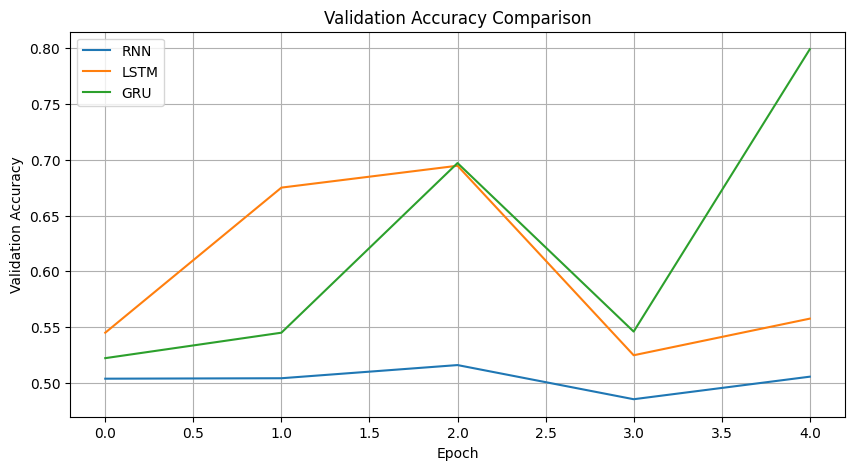

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(history_rnn.history["val_accuracy"], label="RNN")
plt.plot(history_lstm.history["val_accuracy"], label="LSTM")
plt.plot(history_gru.history["val_accuracy"], label="GRU")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## 12. Compare Training Time

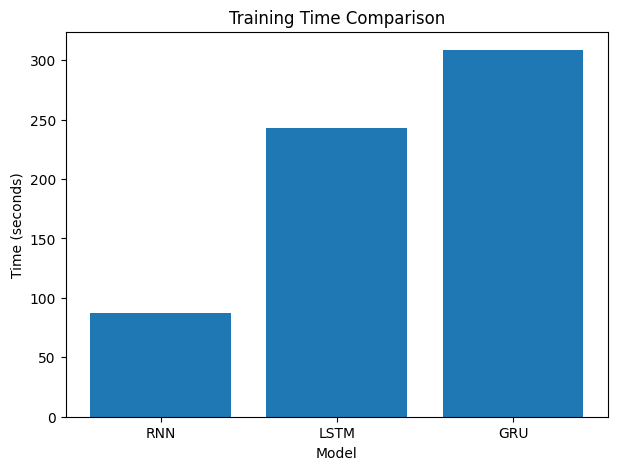

In [12]:
plt.figure(figsize=(7, 5))
plt.bar(comparison.index, comparison["Training Time (sec)"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.show()


## 13. Sample Sentiment Prediction

The function below predicts the sentiment of a new review using each trained model.


In [13]:
word_index = imdb.get_word_index()

def encode_review(text, word_index, vocab_size=VOCAB_SIZE):
    words = re.sub(r"[^a-zA-Z0-9 ]", " ", text.lower()).split()
    sequence = [1]
    for word in words:
        idx = word_index.get(word, 2)
        if idx + 3 < vocab_size:
            sequence.append(idx + 3)
        else:
            sequence.append(2)
    return pad_sequences([sequence], maxlen=MAX_LEN, padding="post", truncating="post")

def predict_sentiment(text):
    x = encode_review(text, word_index)
    models = {
        "RNN": rnn_model,
        "LSTM": lstm_model,
        "GRU": gru_model
    }
    for name, model in models.items():
        probability = float(model.predict(x, verbose=0)[0][0])
        sentiment = "Positive" if probability >= 0.5 else "Negative"
        print(f"{name}: {sentiment} (probability={probability:.4f})")

predict_sentiment("This movie was excellent and I really enjoyed it.")


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
RNN: Positive (probability=0.5488)
LSTM: Positive (probability=0.5293)
GRU: Positive (probability=0.7255)


## 14. Final Analysis

After running all cells, use the generated comparison table to identify the model with the strongest overall combination of Accuracy, Precision, Recall, and F1-score. Training time should also be considered when discussing computational efficiency.

**Important:** Do not enter fixed or fabricated metric values in the report. Copy the actual values produced by this notebook after execution.


## 15. Conclusion

RNN, LSTM, and GRU are recurrent neural network architectures used for sequential text data. Simple RNN is computationally straightforward but can have difficulty retaining long-term information. LSTM introduces memory and gating mechanisms, while GRU uses a simpler gating structure. The final conclusion for this assignment should be based on the actual Accuracy, Precision, Recall, F1-score, and Training Time obtained from the Colab execution.
